# FFT power spectral density

## tl;dr

- EEG is resampled to 125 Hz, demeaned channel-wise, multiplied by a periodic Hann window, and transformed with a real FFT.
- The one-sided periodogram uses density scaling in stored-unit^2/Hz and is rebinned onto the exact 2-40 Hz, 1 Hz grid while preserving band power.
- Synthetic 10 Hz and 23 Hz tones validate peak localization and integrated power before real data are inspected.
- One `exec` and one `patt` block are transformed without changing or duplicating their original EOG arrays.


## Context and methods

This notebook validates spectral preprocessing checkpoint 4. It is a transform demonstration, not an ML experiment and not evidence of a difference between recording families.

For each EEG channel:

1. Polyphase-resample from the source rate to the configured analysis rate.
2. Subtract the channel mean.
3. Apply a periodic Hann window.
4. Compute `scipy.fft.rfft` and scale `abs(X)^2 / (fs * sum(window^2))`.
5. Double non-DC, non-Nyquist bins to obtain a one-sided PSD.
6. Rebin native FFT cells by frequency overlap onto 1 Hz output cells.

The output is global per-block PSD with shape `(channel, frequency)`; it has no time axis.


### 1. Setup


In [1]:
import json
import os
import sys
from pathlib import Path
from time import perf_counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-eeg-fft")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find project root")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from preprocessors import FFTConfig, compute_fft_psd, load_preprocessing_config
from utils.datasets import FFTDataset


config = load_preprocessing_config("fft")
assert isinstance(config, FFTConfig)

pd.Series(
    {
        "project_root": str(PROJECT_ROOT),
        "scipy_version": scipy.__version__,
        "analysis_sfreq_hz": config.analysis_sfreq,
        "frequency_range_hz": f"{config.f_min:g}-{config.f_max:g}",
        "frequency_step_hz": config.frequency_step,
        "window": config.window,
        "demean": config.demean,
        "output_dtype": config.dtype,
    },
    name="FFT configuration",
)


project_root          /home/slauva/Projects/master-thesis-2024-2026/...
scipy_version                                                    1.17.1
analysis_sfreq_hz                                                 125.0
frequency_range_hz                                                 2-40
frequency_step_hz                                                   1.0
window                                                             hann
demean                                                             True
output_dtype                                                    float32
Name: FFT configuration, dtype: object

## Validation

### 2. Synthetic frequency and power checks

The synthetic input is generated at the corpus source rate of 1,000 Hz. A large DC offset is included to verify channel-wise demeaning. For a sinusoid with amplitude `A`, integrated PSD should recover mean-square power `A^2 / 2`.


In [2]:
source_sfreq = 1_000.0
duration_seconds = 8.0
time = np.arange(int(source_sfreq * duration_seconds), dtype=np.float64) / source_sfreq
synthetic_specs = [
    {"channel": "tone_10_hz", "frequency_hz": 10.0, "amplitude": 2.0, "offset": 100.0},
    {"channel": "tone_23_hz", "frequency_hz": 23.0, "amplitude": 0.5, "offset": -20.0},
]
synthetic_eeg = np.stack(
    [
        spec["offset"]
        + spec["amplitude"] * np.sin(2.0 * np.pi * spec["frequency_hz"] * time)
        for spec in synthetic_specs
    ]
)

synthetic_result = compute_fft_psd(
    synthetic_eeg,
    source_sfreq=source_sfreq,
    config=config,
)

synthetic_rows = []
for channel_index, spec in enumerate(synthetic_specs):
    detected_frequency = float(
        synthetic_result.frequencies[np.argmax(synthetic_result.eeg_power[channel_index])]
    )
    integrated_power = float(
        synthetic_result.eeg_power[channel_index].sum() * config.frequency_step
    )
    expected_power = spec["amplitude"] ** 2 / 2.0
    synthetic_rows.append(
        {
            "channel": spec["channel"],
            "expected_peak_hz": spec["frequency_hz"],
            "detected_peak_hz": detected_frequency,
            "expected_power": expected_power,
            "integrated_2_40_hz_power": integrated_power,
            "relative_power_error": abs(integrated_power - expected_power) / expected_power,
        }
    )

synthetic_summary = pd.DataFrame(synthetic_rows).set_index("channel")
display(synthetic_summary)

assert synthetic_result.eeg_power.shape == (2, 39)
assert synthetic_result.eeg_power.dtype == np.float32
assert synthetic_result.times is None
assert np.array_equal(synthetic_summary["detected_peak_hz"], synthetic_summary["expected_peak_hz"])
assert (synthetic_summary["relative_power_error"] < 1e-3).all()


,expected_peak_hz,detected_peak_hz,expected_power,integrated_2_40_hz_power,relative_power_error
channel,,,,,
tone_10_hz,10.0,10.0,2.000,2.001444,0.000722
tone_23_hz,23.0,23.0,0.125,0.125011,0.000091


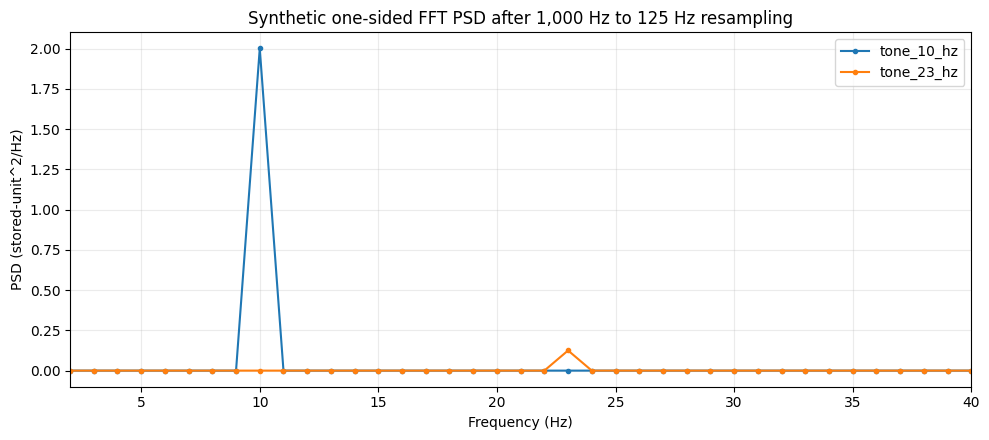

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for channel_index, spec in enumerate(synthetic_specs):
    ax.plot(
        synthetic_result.frequencies,
        synthetic_result.eeg_power[channel_index],
        marker="o",
        markersize=3,
        label=spec["channel"],
    )
ax.set(
    title="Synthetic one-sided FFT PSD after 1,000 Hz to 125 Hz resampling",
    xlabel="Frequency (Hz)",
    ylabel="PSD (stored-unit^2/Hz)",
    xlim=(config.f_min, config.f_max),
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## Real data

### 3. Transform one `exec` and one `patt` block

The first canonical block in each stable dataset index is used. These examples demonstrate I/O, metadata, output contracts, and caching only; they are not selected as representative observations.


In [4]:
family_settings = {
    "exec": {
        "dataset_dir": PROJECT_ROOT / "data" / "Data_Train",
        "dataset_step_type": "exec",
    },
    "patt": {
        "dataset_dir": PROJECT_ROOT / "data" / "Data_Pattern",
        "dataset_step_type": "patt",
    },
}

real_datasets = {}
real_samples = {}
real_rows = []
for family, settings in family_settings.items():
    dataset = FFTDataset(**settings, source_cache_policy=None)
    first_start = perf_counter()
    sample = dataset[0]
    first_seconds = perf_counter() - first_start
    cached_start = perf_counter()
    cached_sample = dataset[0]
    cached_seconds = perf_counter() - cached_start

    cache_entry = dataset.get_cache_entry_path(0)
    cache_bytes = sum(path.stat().st_size for path in cache_entry.iterdir() if path.is_file())
    real_datasets[family] = dataset
    real_samples[family] = sample
    real_rows.append(
        {
            "family": family,
            "key": (
                sample.sample.subject_id,
                sample.sample.trial_number,
                sample.sample.block_index,
            ),
            "source_shape": dataset.source_dataset[0].eeg.shape,
            "output_shape": sample.eeg_power.shape,
            "source_sfreq_hz": sample.source_sfreq,
            "analysis_sfreq_hz": sample.analysis_sfreq,
            "eog_shape": sample.eog.shape,
            "eog_nan_fraction": float(np.isnan(sample.eog).mean()),
            "first_access_seconds": first_seconds,
            "cached_access_seconds": cached_seconds,
            "artifact_kib": cache_bytes / 1024.0,
        }
    )
    np.testing.assert_array_equal(cached_sample.eeg_power, sample.eeg_power)

real_summary = pd.DataFrame(real_rows).set_index("family")
display(real_summary)

for family, sample in real_samples.items():
    assert sample.eeg_power.shape == (63, 39), family
    assert sample.eeg_power.dtype == np.float32, family
    assert sample.frequencies.shape == (39,), family
    assert sample.times is None, family
    assert np.isfinite(sample.eeg_power).all(), family
    assert np.all(sample.eeg_power >= 0), family
    assert sample.eog is not None, family


,key,source_shape,output_shape,source_sfreq_hz,analysis_sfreq_hz,eog_shape,eog_nan_fraction,first_access_seconds,cached_access_seconds,artifact_kib
family,,,,,,,,,,
exec,"(1, 1, 1)","(63, 16001)","(63, 39)",1000.0,125.0,"(5, 16001)",0.000000,0.011209,0.008150,12.000000
patt,"(1, 1, 1)","(63, 26001)","(63, 39)",1000.0,125.0,"(5, 26001)",0.057059,0.010251,0.009853,12.003906


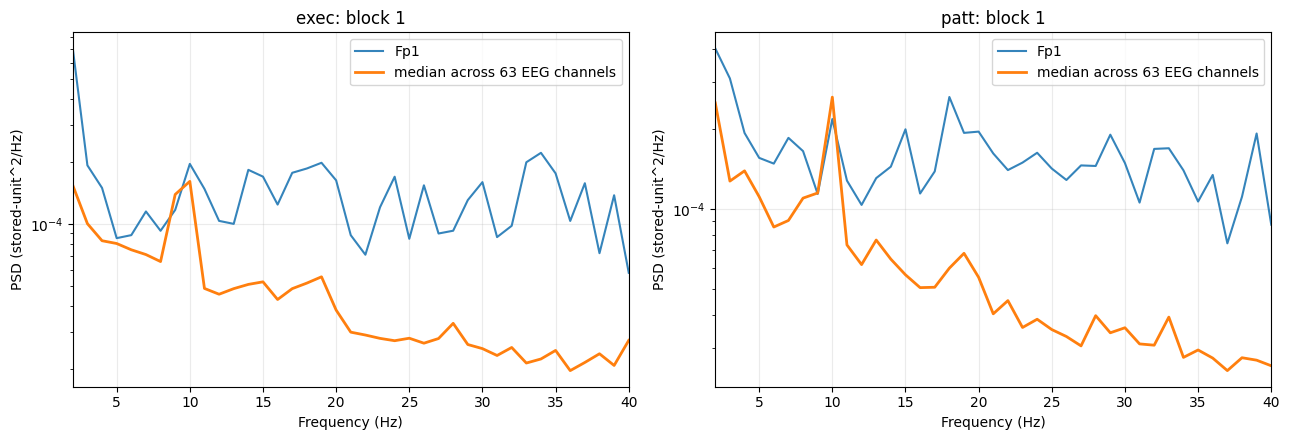

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for ax, (family, sample) in zip(axes, real_samples.items(), strict=True):
    first_channel = sample.eeg_channels[0]
    ax.semilogy(
        sample.frequencies,
        sample.eeg_power[0],
        label=first_channel,
        alpha=0.9,
    )
    ax.semilogy(
        sample.frequencies,
        np.median(sample.eeg_power, axis=0),
        label="median across 63 EEG channels",
        linewidth=2,
    )
    ax.set(
        title=f"{family}: block {sample.sample.block_index}",
        xlabel="Frequency (Hz)",
        ylabel="PSD (stored-unit^2/Hz)",
        xlim=(config.f_min, config.f_max),
    )
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()


### 4. Inspect cache manifests

Only spectral power, the frequency axis, and a manifest are stored. EOG is read from the current source dataset on every access.


In [6]:
manifest_rows = []
for family, dataset in real_datasets.items():
    entry = dataset.get_cache_entry_path(0)
    manifest = json.loads((entry / "manifest.json").read_text(encoding="utf-8"))
    files = sorted(path.name for path in entry.iterdir() if path.is_file())
    manifest_rows.append(
        {
            "family": family,
            "config_hash": manifest["config_hash"],
            "files": files,
            "power_shape": tuple(manifest["arrays"]["eeg_power"]["shape"]),
            "power_dtype": manifest["arrays"]["eeg_power"]["dtype"],
            "times": manifest["arrays"]["times"],
            "sources": sorted(manifest["sources"]),
        }
    )
    assert files == ["eeg_power.npy", "frequencies.npy", "manifest.json"]

display(pd.DataFrame(manifest_rows).set_index("family"))


,config_hash,files,power_shape,power_dtype,times,sources
family,,,,,,
exec,64a9cf2eeb60db99,"[eeg_power.npy, frequencies.npy, manifest.json]","(63, 39)",float32,None,"[eeg, eog]"
patt,64a9cf2eeb60db99,"[eeg_power.npy, frequencies.npy, manifest.json]","(63, 39)",float32,None,"[eeg, eog]"


## Takeaways

1. Synthetic peaks are recovered on the exact configured frequency grid after 8x downsampling.
2. Integrated PSD recovers sinusoidal mean-square power, supporting the density normalization and 1 Hz rebinning contract.
3. Both real recording families produce finite non-negative `(63, 39)` `float32` outputs with no time axis.
4. Original EOG remains auxiliary source data and is not duplicated in FFT artifacts.
5. The global FFT representation summarizes each complete block; later time-frequency methods are required for within-block timing.
